In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scienceplots
import seaborn as sns

from nanonets import Simulation
from nanonets.utils import load_simulation_results

plt.style.use(["science","bright","grid"])

# PARAMETERS
M_VALS  = [1,2,4,8,16,32,64,128,256,512,1024,2048,4096,8192,16384]
L_VALS  = [3,9,15]
T_VALS  = [0.1]
PATH    = "/mnt/c/Users/jonas/Desktop/phd/data/1_funding_period/iv_curves/stats_jumps/"

# INPUT VOLTAGES
V_INPUT_MAX = 0.2
N_INPUTS    = 5
V_INPUT     = np.round(np.linspace(0.03, V_INPUT_MAX, N_INPUTS),4)

In [6]:
df = pd.DataFrame()
for L in L_VALS:
    for T in T_VALS:
        for M in M_VALS:
            try:
                df_tmp      = pd.read_csv(f"{PATH}Nx={L}_Ny={L}_Ne=8_{M}_{T}.csv")
                df_tmp['L'] = L
                df_tmp['T'] = T
                df          = pd.concat([df,df_tmp],ignore_index=True)
            except:
                pass

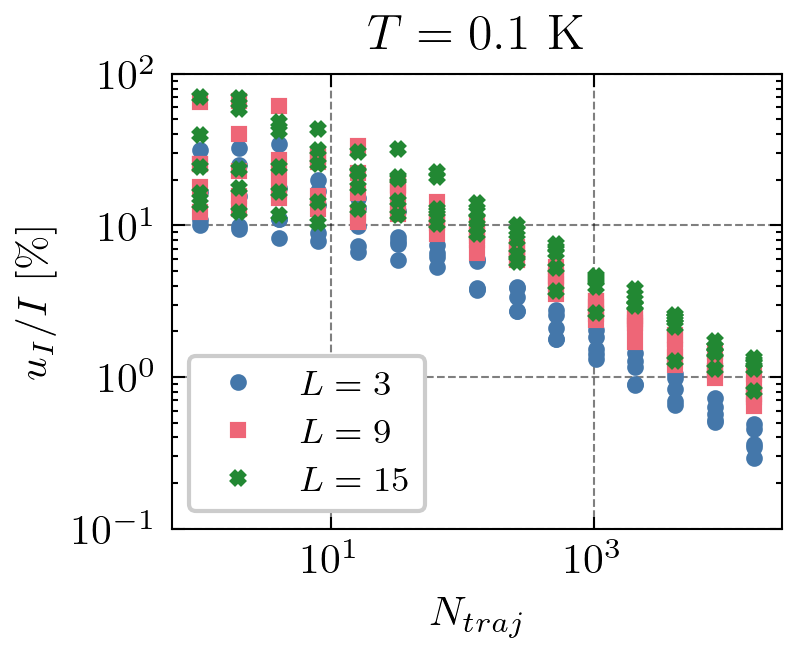

In [7]:
T       = 0.1
i       = 0
df_tmp  = df.copy()
# df_tmp  = df_tmp[df_tmp['E0']==V_INPUT[i]]
df_tmp  = df_tmp[df_tmp['T']==T]
marker  = ['o','s','X']

fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)

for i, L in enumerate(L_VALS):
    val = df_tmp[df_tmp['L']==L]
    _   = ax.plot(val['Jumps'], 100*val['Error']/val['Observable'], marker[i], label=f'$L = {L}$', markersize=3)

# _   = ax.plot(M_VALS, -1/np.sqrt(M_VALS)+10, color=black)
_   = ax.set_xscale('log')
_   = ax.set_yscale('log')
_   = ax.set_xlabel("$N_{traj}$")
_   = ax.set_ylabel("$u_I/I~[\mathrm{\%}]$")
_   = ax.legend(fontsize='small', loc='lower left')
_   = ax.set_ylim(1e-1,1e2)
_   = ax.set_title("$T = 0.1~\mathrm{K}$")

fig.savefig(f"plots/svg/relative_error_vs_traj_jumps.svg", transparent=True)
fig.savefig(f"plots/pdf/relative_error_vs_traj_jumps.pdf", transparent=False)
fig.savefig(f"plots/png/relative_error_vs_traj_jumps.png", transparent=False)